In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [56]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame


In [57]:
print(df)

          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  target  
0   -0.002592  0.019907 -0.0176

In [58]:
X = df.drop(columns=['target'])
y = df['target']

print("Dataset Shape:", df.shape)
print("\nFeature Columns:\n", X.columns.tolist())

Dataset Shape: (442, 11)

Feature Columns:
 ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

If we use fit_transform for test data it will gets its OWN mean/std, which is WRONG! The model was trained on training data's scale, so test data must use the SAME scale.

In [61]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [62]:
y_pred = model.predict(X_test_scaled)


In [63]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [64]:
print("\n--- Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score : {r2:.2f}")


--- Model Performance ---
Mean Squared Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
R-squared Score : 0.45


In [65]:
coefficients = pd.Series(model.coef_, index=X.columns)

print("\n--- Model Coefficients ---")
print(coefficients)


--- Model Coefficients ---
age     1.753758
sex   -11.511809
bmi    25.607121
bp     16.828872
s1    -44.448856
s2     24.640954
s3      7.676978
s4     13.138784
s5     35.161195
s6      2.351364
dtype: float64


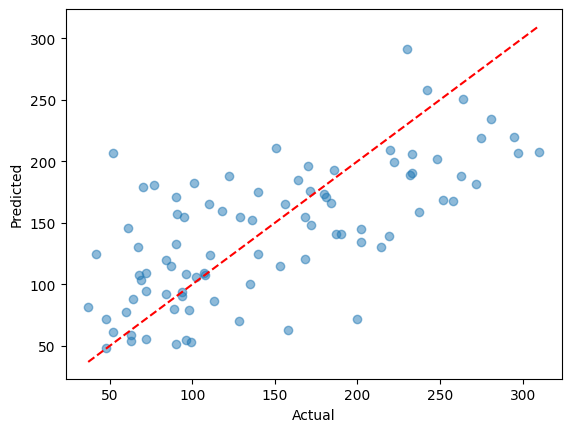

In [66]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()